# ECB Speeches NLP Project

This notebook analyses speeches from the European Central Bank (ECB). It covers:

- Cleaning and structuring the raw CSV dataset.
- Filtering to English-only speeches with an explicit `language` column.
- Normalising speakers and assigning ECB role labels for every retained speaker.
- Text preprocessing with **two** token/lemma sets: one for topic modelling, one for sentiment analysis.
- A concise descriptive overview of the final corpus.

## 1. Imports and configuration

Load all required libraries. If `spacy` or `langdetect` are missing, run the commented install lines once.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

import spacy
# in the terminal, if not downloaded already: pip install langdetect spacy AND !python -m spacy download en_core_web_sm
from langdetect import detect, LangDetectException
import nltk

plt.style.use("seaborn-v0_8")
sns.set_palette("muted")

# for sentiment analysis:
# nltk.download("vader_lexicon", quiet=True)

nlp = spacy.load("en_core_web_sm")
print("Libraries loaded.")

Libraries loaded.


## 2. Data loading

Reads the ECB speeches CSV. Expected columns: `date`, `speakers`, `title`, `subtitle`, `contents`.
Adjust `INPUT_PATH` as needed.

In [2]:
INPUT_PATH = "all_ECB_speeches.csv" 

# The ECB speeches file is structured as:
#   - Pipe-separated (|)
#   - UTF-8 encoded (no BOM)
#   - CRLF line endings 
#   - No quoting character
#   - fill=TRUE equivalent: warning, not crashed

raw = pd.read_csv(
    INPUT_PATH,
    sep="|",           # pipe delimiter
    quoting=3,         # csv.QUOTE_NONE 
    encoding="utf-8",  # UTF-8
    dtype=str,         # keeping everything as string for now
    on_bad_lines="warn",  # fill=TRUE equivalent: warn and skip malformed rows
)

# Strip the UTF-8 BOM from the first column name if present
raw.columns = [c.lstrip("\ufeff").strip() for c in raw.columns]

print("Shape:", raw.shape)
print("Columns:", raw.columns.tolist())
raw.head(3)

Shape: (3007, 5)
Columns: ['date', 'speakers', 'title', 'subtitle', 'contents']


,date,speakers,title,subtitle,contents
0,2026-03-27,Isabel Schnabel,Monetary policy in times of geopolitical fragm...,"Slides by Isabel Schnabel, Member of the Execu...",NaN
1,2026-03-26,Luis de Guindos,Navigating turbulence: challenges for Europe a...,"Speech by Luis de Guindos, Vice-President of t...",SPEECH Navigating turbulence: challenges fo...
2,2026-03-25,NaN,The outlook for the euro area economy,"Slides by Philip R. Lane, Member of the Execut...",NaN


In [3]:
# Data Description 
print(raw.info)

print('Missing values per column:')
print(raw.isna().sum())


<bound method DataFrame.info of             date              speakers  \
0     2026-03-27       Isabel Schnabel   
1     2026-03-26       Luis de Guindos   
2     2026-03-25                   NaN   
3     2026-03-25     Christine Lagarde   
4     2026-03-24       Piero Cipollone   
...          ...                   ...   
3002  1997-05-13  Alexandre Lamfalussy   
3003  1997-04-30  Alexandre Lamfalussy   
3004  1997-04-22  Alexandre Lamfalussy   
3005  1997-03-10  Alexandre Lamfalussy   
3006  1997-02-07  Alexandre Lamfalussy   

                                                  title  \
0     Monetary policy in times of geopolitical fragm...   
1     Navigating turbulence: challenges for Europe a...   
2                 The outlook for the euro area economy   
3     Navigating energy shocks: risks and policy res...   
4     The digital euro: preparing for a potential la...   
...                                                 ...   
3002  The European Central Bank: independent and a

count      2857.000000
mean      19710.903395
std       12049.752518
min           1.000000
25%       11840.000000
50%       17545.000000
75%       25042.000000
max      113165.000000
Name: length, dtype: float64


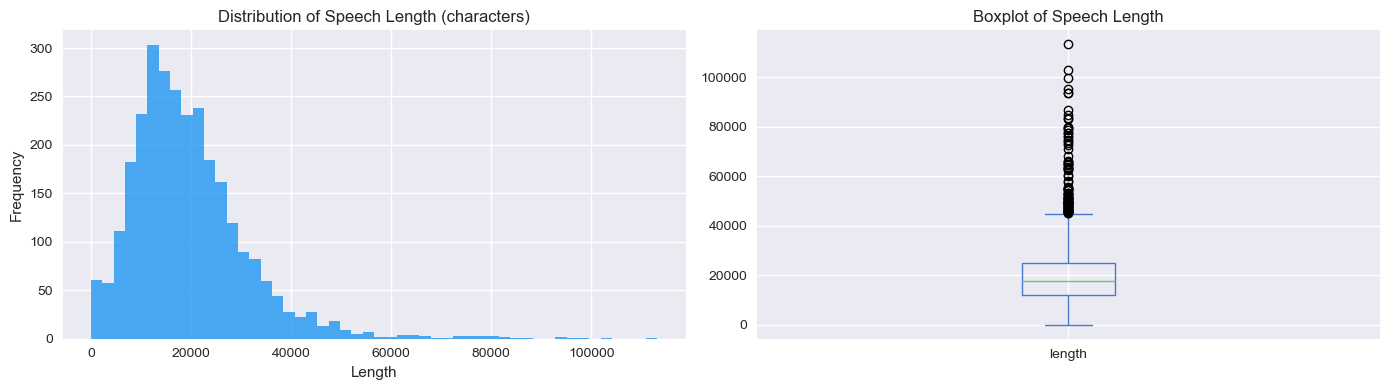

In [4]:
# Adding a length column (for the character count of contents)
raw["length"] = raw["contents"].str.len()

# Descriptive statistics
print(raw["length"].describe())

# Creating distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

raw["length"].plot(kind="hist", bins=50, ax=axes[0], color="#2196F3", alpha=0.8)
axes[0].set_title("Distribution of Speech Length (characters)")
axes[0].set_xlabel("Length")

raw["length"].plot(kind="box", ax=axes[1])
axes[1].set_title("Boxplot of Speech Length")

plt.tight_layout()
plt.show()

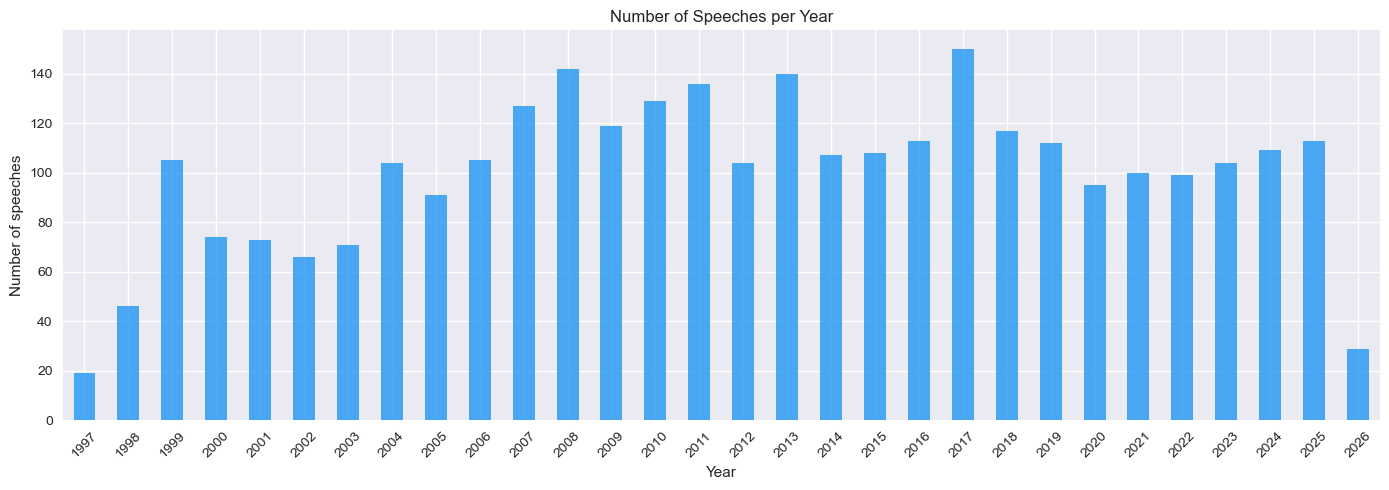

In [5]:
# Visualizing number of speeches per year
raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw["year"] = raw["date"].dt.year

raw.groupby("year").size().plot(kind="bar", figsize=(14, 5),
                                 title="Number of Speeches per Year",
                                 color="#2196F3", alpha=0.8)
plt.xlabel("Year")
plt.ylabel("Number of speeches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Cleaning, schema and unified text field

This section:

- Strips whitespace and common encoding features.
- Removes footnote / boilerplate blocks from `contents` before building the text field.
- Builds a unified `textraw` field as the concatenation of `title`, `subtitle`, and cleaned `contents`.
- Drops slide-only speeches: rows whose subtitle signals a slides/presentation format, or
  whose cleaned text is too short to be analytically meaningful (< 50/100 characters after stripping; modifying this).
- Drops rows with completely empty text.

In [6]:
EXPECTED = ["date", "speakers", "title", "subtitle", "contents"]
missing = [c for c in EXPECTED if c not in raw.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df = raw[EXPECTED].copy()
n_original = len(df) 

# Normalise whitespace and non-breaking spaces
for col in EXPECTED:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("\u00a0", " ", regex=False)
        .str.replace("\r", " ", regex=False)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )

# Parse dates 
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors="coerce")


# Step A: Remove footnote / boilerplate blocks from contents 
# Footnotes in ECB speeches have:
#   - Numbered reference lines: "1.", "[1]", superscript-like numbers at line start
#   - Citation starters: lines beginning with "See ", "Cf.", "Source:", "Note:"
#   - Slide-caption boilerplate: "Chart", "Figure", "Table" followed by a number
# We split on double-whitespace (paragraph breaks), then drop paragraphs that look like footnote / caption blocks.

FOOTNOTE_PATTERNS = re.compile(
    r"^("
    r"\[?\d+\]?\.?\s"           # [1] or 1. at start
    r"|\d+\.\s"                 # 1. at start
    r"|See\s"                   # See ...
    r"|Cf\.\s"                  # Cf. ...
    r"|Source:"                 # Source:
    r"|Note:"                   # Note:
    r"|Chart\s\d"               # Chart 1
    r"|Figure\s\d"              # Figure 1
    r"|Table\s\d"               # Table 1
    r"|Graph\s\d"               # Graph 1
    r")",
    re.IGNORECASE
)

def strip_footnotes(text: str) -> str:
    if pd.isna(text) or not str(text).strip():
        return ""
    # 1. Removing inline footnote markers:
    text = re.sub(r"(?<=\w)\d{1,2}(?=\s|,|\.|\))", "", text)
    # 2. Spliting into paragraphs and droping footnote-starting ones:
    paragraphs = re.split(r"\s{2,}", str(text))
    clean_paras = [p.strip() for p in paragraphs
                   if p.strip() and not FOOTNOTE_PATTERNS.match(p.strip())]
    return " ".join(clean_paras)


df["contents"] = df["contents"].apply(strip_footnotes)

# This is to prevent double counting of the content, if any:
df["contents"] = df["contents"].str.replace(
    r"^\s*SPEECH\s+", "", regex=True
).str.strip()


# Step B: Flag and drop slide-only speeches 
# Primary: Subtitle contains slide/presentation keywords
SLIDE_PATTERN = re.compile(
    r"\b(slides?|presentation|charts?|figures?|overhead)\b",
    re.IGNORECASE
)
df["is_slides"] = df["subtitle"].apply(
    lambda s: bool(SLIDE_PATTERN.search(str(s)))
)

n_slides = df["is_slides"].sum()
print(f"Slide-only speeches detected via subtitle: {n_slides}")
if n_slides:
    print(df.loc[df["is_slides"], ["date", "speakers", "subtitle"]].head(5).to_string())

df = df[~df["is_slides"]].drop(columns=["is_slides"]).reset_index(drop=True)


# Step C: Build unified textraw 
def safe_str(x):
    return "" if pd.isna(x) else str(x)

# Replaced this istead of the block below to prevent double counting of the content if any
def build_textraw(row):
    title    = safe_str(row["title"]).strip()
    subtitle = safe_str(row["subtitle"]).strip()
    contents = safe_str(row["contents"]).strip()
    
    # Try all possible duplicate prefixes, longest first
    for prefix in [title + " " + subtitle, subtitle, title]:
        if prefix and contents.startswith(prefix):
            contents = contents[len(prefix):].strip()
            break
    
    return f"{title} {subtitle} {contents}".strip()

df["textraw"] = df.apply(build_textraw, axis=1)

#df["textraw"] = (
#    df["title"].apply(safe_str) + " " +
#    df["subtitle"].apply(safe_str) + " " +
#    df["contents"].apply(safe_str)
#).str.strip().replace("", pd.NA)

n_before = len(df)
df = df.dropna(subset=["textraw"]).reset_index(drop=True)

# Secondary: drop rows whose textraw is still suspiciously short (to catch slides that slipped past the subtitle filter)
MIN_CHARS = 100
short_mask = df["textraw"].str.len() < MIN_CHARS
n_short = short_mask.sum()
if n_short:
    print(f"\nAdditionally dropping {n_short} rows with textraw < {MIN_CHARS} chars (likely slides/empty):")
    print(df.loc[short_mask, ["date", "speakers", "subtitle"]].head(5).to_string())
df = df[~short_mask].reset_index(drop=True)

#print(f"\nRows retained after all cleaning: {len(df)}  (dropped {n_before - len(df)} from original)")
# Modified to show all drops from the original dataset, not only the last step:
print(f"Rows retained: {len(df)}  (dropped {n_original - len(df)} total from original {n_original})")
df[["date", "speakers", "title", "textraw"]].head(3)

Slide-only speeches detected via subtitle: 171
         date         speakers                                                                                                                                                                                         subtitle
0  2026-03-27  Isabel Schnabel                                 Slides by Isabel Schnabel, Member of the Executive Board of the European Central Bank, at Department of Economics at University of Zurich in Zurich, Switzerland
2  2026-03-25              nan                                                                      Slides by Philip R. Lane, Member of the Executive Board of the ECB, at The ECB and Its Watchers XXVI, in Frankfurt, Germany
7  2026-03-21  Piero Cipollone                                                              Slides by Piero Cipollone, Member of the Executive Board of the ECB, at BRIE-CITRIS, Bruegel and the Bank of Finland Joint Workshop
10 2026-03-06  Piero Cipollone                           

,date,speakers,title,textraw
0,2026-03-26,Luis de Guindos,Navigating turbulence: challenges for Europe a...,Navigating turbulence: challenges for Europe a...
1,2026-03-25,Christine Lagarde,Navigating energy shocks: risks and policy res...,Navigating energy shocks: risks and policy res...
2,2026-03-24,Piero Cipollone,The digital euro: preparing for a potential la...,The digital euro: preparing for a potential la...


In [7]:
print(df["speakers"].isna().sum())
print(df[df["speakers"] == "nan"][["date", "title"]].head())
# 2/3 have German titles

df["speakers"] = df["speakers"].replace("nan", pd.NA)
print(f"Rows with missing speakers: {df['speakers'].isna().sum()}")

# Dropping the rows with no speaker identified
n_before = len(df)
df = df.dropna(subset=["speakers"]).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} rows with missing speakers")
print(f"Remaining: {len(df)} speeches")

0
          date                                         title
262 2023-02-07  Monetary policy in times of pandemic and war
399 2021-06-22   Die Geldpolitik der EZB in der Corona-Krise
421 2021-03-18   Die Geldpolitik der EZB in der Corona-Krise
Rows with missing speakers: 3
Dropped 3 rows with missing speakers
Remaining: 2831 speeches


## 4. Language detection and English-only filter

Each speech is assigned a `language` label using `langdetect`.

Design notes:
- Texts shorter than 50 characters are tagged as `'en'` by default rather than dropped.
- An `assert` statement guarantees only English speeches remain after filtering.
- The `language` column is retained for auditability.

In [8]:
MIN_LEN = 50   # chars below which we skip detection and default to 'en'

def detect_language(text):
    if pd.isna(text) or not str(text).strip():
        return "other"
    text = str(text).strip()
    if len(text) < MIN_LEN:
        return "en"   # keep short texts; flag rather than drop if any
    try:
        return "en" if detect(text) == "en" else "other"
    except LangDetectException:
        return "other"

df["language"] = df["textraw"].apply(detect_language)
print("Language distribution:")
print(df["language"].value_counts(dropna=False))

# Dropping non-English speeches and show which speakers are mainly affected
dropped = df[df["language"] != "en"]
if len(dropped):
    print("\nTop speakers in dropped (non-English) rows:")
    print(dropped["speakers"].value_counts().head(10))

df = df[df["language"] == "en"].reset_index(drop=True)

# Invariant check
assert set(df["language"]) == {"en"}, "Non-English rows still present!"
print(f"\nAfter filtering: {len(df)} English speeches retained.")

Language distribution:
language
en       2668
other     163
Name: count, dtype: int64

Top speakers in dropped (non-English) rows:
speakers
José Manuel González-Páramo    24
Jürgen Stark                   22
Gertrude Tumpel-Gugerell       22
Otmar Issing                   17
Eugenio Domingo Solans         17
Jörg Asmussen                  14
Jean-Claude Trichet            10
Yves Mersch                     9
Willem F. Duisenberg            8
Lorenzo Bini Smaghi             5
Name: count, dtype: int64

After filtering: 2668 English speeches retained.


In [9]:
# Checking how many were defaulted to 'en' due to their short length
short_en = df[df["textraw"].str.len() < 50]
print(f"Speeches kept by default (textraw < 50 chars): {len(short_en)}")
print(short_en[["date", "speakers", "textraw"]].head())

Speeches kept by default (textraw < 50 chars): 0
Empty DataFrame
Columns: [date, speakers, textraw]
Index: []


## 5. Speaker normalisation and ECB role labels

- The `speakers` field may contain multiple names separated by commas or semicolons.
- The DataFrame is exploded so each row represents one `(date, speaker, speech)`.
- Every retained speaker is assigned a `speaker_role` from a curated mapping.

**Role taxonomy:**
- `President` – ECB Presidents (Duisenberg, Trichet, Draghi, Lagarde)
- `Executive Board Member` – non-president Executive Board members
- `Other ECB Official` – fallback for speakers not in the map

Extend `ROLE_MAP` as you encounter new names in your full dataset.

In [10]:
# Clean and split
df["speakers_clean"] = (
    df["speakers"].astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

def split_speakers(s):
    if not s or pd.isna(s):
        return []
    return [p.strip() for p in re.split(r"[;,]", s) if p.strip()]

df["speaker_list"] = df["speakers_clean"].apply(split_speakers)

# Explode to one row per speaker
df_exp = df.explode("speaker_list").rename(columns={"speaker_list": "speaker"})
df_exp = df_exp.dropna(subset=["speaker"]).reset_index(drop=True)
print(f"Rows after explosion: {len(df_exp)}")

# ECB role mapping 
ROLE_MAP = {
    # Presidents
    "Christine Lagarde":           "President",
    "Mario Draghi":                "President",
    "Jean-Claude Trichet":         "President",
    "Willem F. Duisenberg":        "President",
    "Wim Duisenberg":              "President",
    # Executive Board Members
    "Piero Cipollone":             "Executive Board Member",
    "Isabel Schnabel":             "Executive Board Member",
    "Luis de Guindos":             "Executive Board Member",
    "Philip Lane":                 "Executive Board Member",
    # Due to variations in naming:
    "Philip R. Lane":              "Executive Board Member",
    "Fabio Panetta":               "Executive Board Member",
    "Frank Elderson":              "Executive Board Member",
    "Lorenzo Bini Smaghi":         "Executive Board Member",
    "Jose Manuel Gonzalez-Paramo": "Executive Board Member",
    "José Manuel González-Páramo": "Executive Board Member",
    "Gertrude Tumpel-Gugerell":    "Executive Board Member",
    "Eugenio Domingo Solans":      "Executive Board Member",
    "Otmar Issing":                "Executive Board Member",
    "Jürgen Stark":                "Executive Board Member",
    "Jurgen Stark":                "Executive Board Member",
    "Vítor Constâncio":            "Executive Board Member",
    "Vitor Constancio":            "Executive Board Member",
    "Benoît Coeuré":               "Executive Board Member",
    "Benoît Cœuré":                "Executive Board Member",
    "Peter Praet":                 "Executive Board Member",
    "Yves Mersch":                 "Executive Board Member",
    # I added these based on their past roles; but if you thought of this section differently 
    # like only the present board members, we can delete them:
    "Lucas Papademos":             "Executive Board Member",  # Vice-President 2002-2010
    "Sabine Lautenschläger":       "Executive Board Member",  # 2014-2019
    "Christian Noyer":             "Executive Board Member",  # Vice-President 1998-2002
    "Tommaso Padoa-Schioppa":      "Executive Board Member",  # founding member 1998-2005
    "Sirkka Hämäläinen":           "Executive Board Member",  # 1998-2003
    "Jörg Asmussen":               "Executive Board Member",  # 2012-2014
}

df_exp["speaker_role"] = df_exp["speaker"].map(ROLE_MAP).fillna("Other ECB Official")

# Keep a 'president' column (NaN for non-presidents)
PRESIDENTS = {k for k, v in ROLE_MAP.items() if v == "President"}
df_exp["president"] = df_exp["speaker"].where(df_exp["speaker"].isin(PRESIDENTS))

# Integrity assertions
assert df_exp["speaker"].isna().sum() == 0,       "Missing speaker values!"
assert df_exp["speaker_role"].isna().sum() == 0,  "Missing speaker_role values!"

print("Speaker role counts:")
print(df_exp["speaker_role"].value_counts(dropna=False))
df_exp[["date", "speaker", "speaker_role", "title"]].head(5)

Rows after explosion: 2670
Speaker role counts:
speaker_role
Executive Board Member    1855
President                  808
Other ECB Official           7
Name: count, dtype: int64


,date,speaker,speaker_role,title
0,2026-03-26,Luis de Guindos,Executive Board Member,Navigating turbulence: challenges for Europe a...
1,2026-03-25,Christine Lagarde,President,Navigating energy shocks: risks and policy res...
2,2026-03-24,Piero Cipollone,Executive Board Member,The digital euro: preparing for a potential la...
3,2026-03-23,Philip R. Lane,Executive Board Member,AI and the euro area economy
4,2026-03-23,Piero Cipollone,Executive Board Member,Building the rails for Europe’s tokenised fina...


In [12]:
# Checking who is being classified as "Other ECB Official"
others = df_exp[df_exp["speaker_role"] == "Other ECB Official"]
print(others["speaker"].value_counts().to_string())

speaker
Alexandre Lamfalussy    7


## 6. Text preprocessing and dual stopword strategies

`text_clean` is produced by collapsing whitespace **without lowercasing** — capitalisation
is preserved so that spaCy can reliably detect proper nouns (`PROPN`), foreign words (`X`),
and other POS tags that depend on case.

Tokens are then lowercased **after** POS tagging.

**POS-based filtering:** Tokens tagged as `PROPN` (proper nouns like speaker names, city names),
`X` (foreign words — catches French/German fragments in bilingual passages), `SYM`, or `NUM`
are discarded before any stopword check.

Two token/lemma columns are created:

| Column | Purpose | Stopwords |
|---|---|---|
| `tokens_topic` / `lemmas_topic` | Topic modelling, word frequencies | spaCy defaults + ECB domain words + non-English function words |
| `tokens_sent` / `lemmas_sent` | Sentiment / stylistic analysis | spaCy defaults **minus** pronouns & negations |

The domain stopwords include months, titles/forms of address, citation abbreviations (pp, et, al, cf),
and common French/German/Italian/Spanish function words that survive language detection.

In [13]:
def clean_text(text):
    """Collapse whitespace only — do NOT lowercase yet.
    Lowercasing is deferred until after spaCy POS-tagging so that
    capitalisation cues (proper nouns, sentence starts) remain available
    for the tagger."""
    if pd.isna(text):
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()

df_exp["text_clean"] = df_exp["textraw"].apply(clean_text)

# ── Stopword sets ──────────────────────────────────────────────────────────
# NOTE: all stopwords are stored in lowercase; comparison is always
#       against the lowercased token / lemma (done after POS tagging).
DOMAIN_SW = {
    # ECB boilerplate
    "european", "central", "bank", "ecb", "euro", "area",
    "speech", "remarks", "conference", "panel",
    "opening", "closing", "welcome", "thank", "thanks",
    "today", "tonight", "morning", "afternoon", "evening",
    # Months (often appear in datelines / headers)
    "january", "february", "march", "april", "may", "june",
    "july", "august", "september", "october", "november", "december",
    # Titles / forms of address
    "mr", "mrs", "ms", "dr", "prof", "professor",
    "president", "vice", "chairman", "chairwoman",
    "ladies", "gentlemen", "excellencies",
    "lecture", "organised", "keynote",
    # Common abbreviations & citation fragments that survive cleaning
    "pp", "et", "al", "eg", "ie", "cf", "op", "cit", "ibid",
    "vol", "no", "eds", "ed",
    # Non-English function words that slip through language detection
    # (French, German, Italian, Spanish fragments in bilingual passages)
    "de", "la", "le", "les", "des", "du", "un", "une", "en",
    "je", "il", "ce", "se", "ne", "pas", "que", "qui", "est",
    "et", "ou", "au", "aux", "sur", "dans", "par", "pour", "avec",
    "der", "die", "das", "und", "von", "den", "dem", "ein", "eine",
    "ist", "auf", "für", "mit", "nicht", "auch", "als", "wie",
    "di", "il", "del", "della", "che", "per", "con", "una",
    "el", "los", "las",
}

stopwords_topic = set(nlp.Defaults.stop_words) | DOMAIN_SW

KEEP_FOR_SENT = {"not", "no", "never", "n't", "none", "nobody",
                 "nowhere", "nothing", "neither", "nor",
                 "we", "i", "you", "they", "he", "she"}
stopwords_sent = set(nlp.Defaults.stop_words) - KEEP_FOR_SENT

# ── spaCy batch processing ────────────────────────────────────────────────
# KEY CHANGE: process the ORIGINAL-CASE text so POS tagging is reliable,
# then lowercase the output tokens/lemmas afterward.
# Also filter:  PROPN (proper nouns), X (foreign/unknown), SYM (symbols),
#               NUM-like tokens, single-character tokens.
DISCARD_POS = {"PROPN", "X", "SYM", "NUM", "PUNCT", "SPACE"}

toks_t, lems_t, toks_s, lems_s = [], [], [], []
n_tok_t, n_lem_t, n_tok_s, n_lem_s = [], [], [], []

texts = df_exp["text_clean"].tolist()
print(f"Processing {len(texts)} texts with spaCy (original case for POS)...")

for doc in nlp.pipe(texts, batch_size=64):
    tt, lt, ts, ls = [], [], [], []
    for t in doc:
        # Basic filters: punctuation, spaces, numbers, single chars
        if t.is_punct or t.is_space or t.like_num or len(t.text) <= 1:
            continue
        # Skip unwanted POS (proper nouns, foreign words, symbols)
        if t.pos_ in DISCARD_POS:
            continue
        # Lowercase for output & comparison
        word = t.text.lower()
        lemma = t.lemma_.lower()
        # Topic tokens: apply full stopword set
        if word not in stopwords_topic:
            tt.append(word)
        if lemma not in stopwords_topic:
            lt.append(lemma)
        # Sentiment tokens: keep pronouns & negations
        if word not in stopwords_sent:
            ts.append(word)
        if lemma not in stopwords_sent:
            ls.append(lemma)

    toks_t.append(tt); lems_t.append(lt)
    toks_s.append(ts); lems_s.append(ls)
    n_tok_t.append(len(tt)); n_lem_t.append(len(set(lt)))
    n_tok_s.append(len(ts)); n_lem_s.append(len(set(ls)))

df_exp["tokens_topic"]   = toks_t;  df_exp["lemmas_topic"]   = lems_t
df_exp["tokens_sent"]    = toks_s;  df_exp["lemmas_sent"]    = lems_s
df_exp["num_tok_topic"]  = n_tok_t; df_exp["num_lem_topic"]  = n_lem_t
df_exp["num_tok_sent"]   = n_tok_s; df_exp["num_lem_sent"]   = n_lem_s

# ── Sanity check ──────────────────────────────────────────────────────────
sample = df_exp.iloc[0]
print("\n--- Stopword sanity check (first speech, first 20 topic tokens) ---")
print(sample["tokens_topic"][:20])
print("\n--- First 20 sentiment tokens (note pronouns/negations kept) ---")
print(sample["tokens_sent"][:20])

# Quick check: any obvious junk still present?
all_topic_tokens = [tok for toks in df_exp["tokens_topic"] for tok in toks]
from collections import Counter
top100 = Counter(all_topic_tokens).most_common(100)
suspect = [w for w, c in top100 if len(w) <= 2 or w in ("mr", "sirkka", "inen", "pes", "je", "de", "la")]
if suspect:
    print(f"\n*** WARNING: suspect tokens in top-100: {suspect}")
else:
    print(f"\n*** OK: no obvious junk in top-100 topic tokens")

print("\nProcessing complete.")
df_exp[["speaker", "speaker_role", "num_tok_topic", "num_tok_sent"]].head(5)

Processing 2670 texts with spaCy (original case for POS)...

--- Stopword sanity check (first speech, first 20 topic tokens) ---
['navigating', 'turbulence', 'challenges', 'path', 'ahead', 'introduction', 'privilege', 'deliver', 'memory', 'widely', 'regarded', 'intellectual', 'fathers', 'post', 'war', 'system', 'work', 'showed', 'external', 'shocks']

--- First 20 sentiment tokens (note pronouns/negations kept) ---
['navigating', 'turbulence', 'challenges', 'path', 'ahead', 'organised', 'introduction', 'privilege', 'deliver', 'lecture', 'memory', 'widely', 'regarded', 'intellectual', 'fathers', 'post', 'war', 'system', 'work', 'showed']

*** OK: no obvious junk in top-100 topic tokens

Processing complete.


,speaker,speaker_role,num_tok_topic,num_tok_sent
0,Luis de Guindos,Executive Board Member,951,1008
1,Christine Lagarde,President,1291,1412
2,Piero Cipollone,Executive Board Member,1427,1617
3,Philip R. Lane,Executive Board Member,5851,6161
4,Piero Cipollone,Executive Board Member,1048,1125


In [ ]:
# This I am adding if we want to modify the stowords or fix some earlier mistakes, so that we can test on the saved 
# dataset first then implement in the final run because each time it takes 40mins for me to run the cell above
import pickle
with open("df_exp_processed.pkl", "wb") as f:
    pickle.dump(df_exp, f)
print("Saved!")

## PROBLEM: It does not save due to large size; so if you want to check you need to delete the file before comitting any changes

# To use the saved data, uncomment
#import pickle
#with open("df_exp_processed.pkl", "rb") as f:
#    df_exp = pickle.load(f)
#print(f"Loaded: {len(df_exp)} rows")

Saved!


In [23]:
# Token number was too high for this, seems like the title and content is duplicated; adding another command above to fix this.
# I modified the codes above to account for possible duplication of title/subtitle in the content, 
# then I realized this particular speech is just long, nothing was a bug. But still kept the code modified
print(df_exp.loc[3, "textraw"][:500])
print(f"\nTotal chars: {len(df_exp.loc[3, 'textraw'])}")

AI and the euro area economy Keynote speech by Philip R. Lane, Member of the Executive Board of the ECB, at ECB-SAFE-RCEA International Conference on the Climate-Macro-Finance Interface (3CMFI) SPEECH AI and the euro area economy Keynote speech by Philip R. Lane, Member of the Executive Board of the ECB, at ECB-SAFE-RCEA International Conference on the Climate-Macro-Finance Interface (3CMFI) Frankfurt, 2 March 20 Introduction Artificial intelligence (AI) stands out as a potentially-transformativ

Total chars: 88042


## 7. Concise descriptive analysis

Three outputs:
1. A summary table of the corpus.
2. Top-10 speakers by number of speeches, coloured by role.
3. Annual speech counts by speaker role.

=== 7.1  Corpus summary ===


,Value
Metric,
Total rows (1 row = 1 speaker × 1 speech),2671
Unique speakers,28
Unique roles,3
Date range,1997-02-07 → 2026-03-26
Min words / speech (topic tokens),13
Median words / speech (topic tokens),1366
Max words / speech (topic tokens),8360
Mean words / speech (topic tokens),1534.5


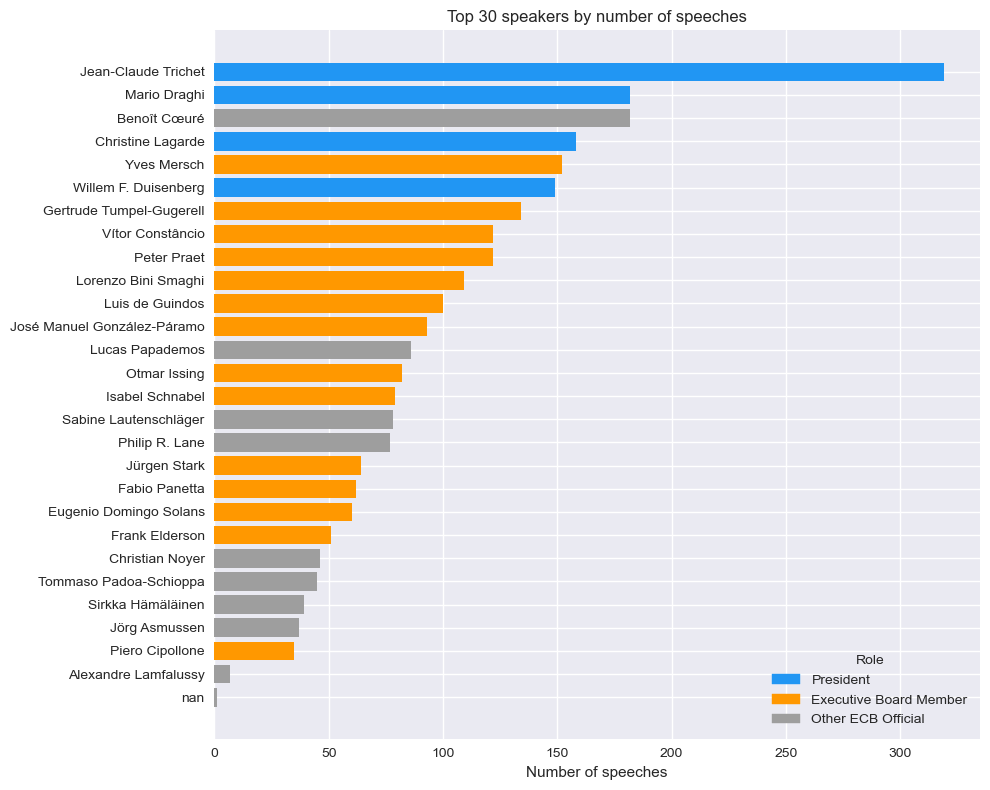

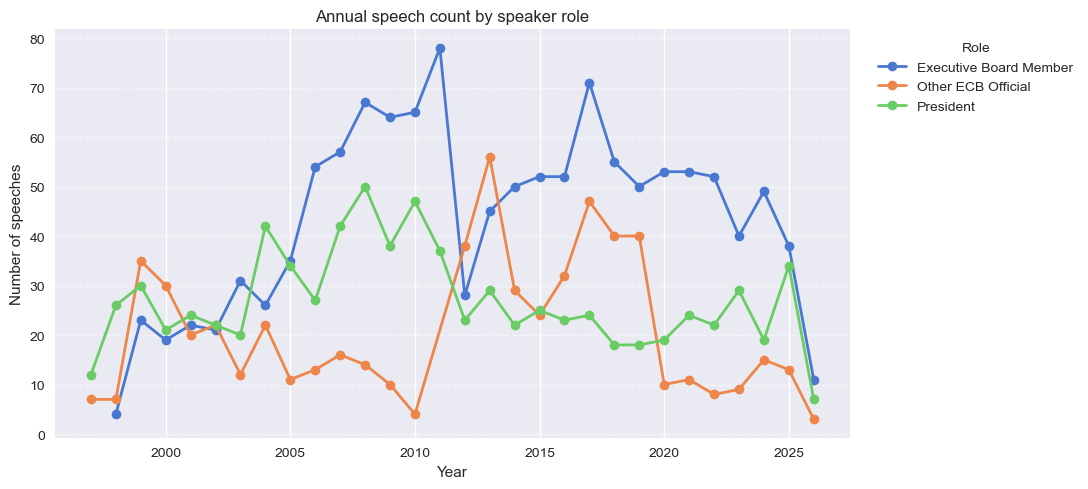

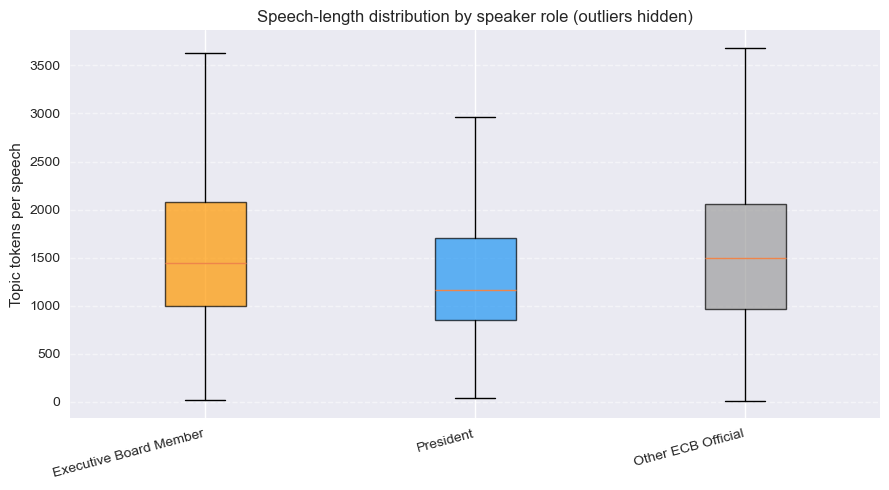


=== 7.5  Word-count statistics by speaker role ===


,n_speeches,median,mean,std,p25,p75
speaker_role,,,,,,
Other ECB Official,598,1494.0,1618.3,1023.6,968.2,2058.5
Executive Board Member,1265,1441.0,1600.5,861.0,995.0,2076.0
President,808,1164.5,1369.2,891.5,851.0,1700.0



=== 7.6  Top 20 content words per speaker role ===

[Executive Board Member]
  financial (24398), policy (23087), monetary (20264), 20 (19034), banks (14794), market (13013), economic (11786), inflation (11732), stability (10063), risk (8174), markets (8095), growth (8061), price (7920), countries (7730), crisis (7508), banking (6987), term (6924), rates (6810), economy (6526), rate (6415)

[President]
  policy (11732), monetary (11359), financial (11095), 20 (8581), economic (8349), inflation (7167), growth (6869), stability (6715), market (6378), price (6044), countries (5300), banks (4815), term (4633), markets (4527), economy (4142), europe (3980), rates (3806), new (3662), time (3642), rate (3439)

[Other ECB Official]
  policy (11490), monetary (10160), financial (9963), 20 (9435), banks (6932), market (6589), economic (5729), inflation (5688), stability (4692), growth (4330), rate (4229), countries (3968), markets (3903), term (3900), price (3882), risk (3874), rates (3783), ba

,median,mean,std
speaker_role,,,
President,0.483,0.482,0.087
Executive Board Member,0.440,0.446,0.082
Other ECB Official,0.437,0.452,0.110


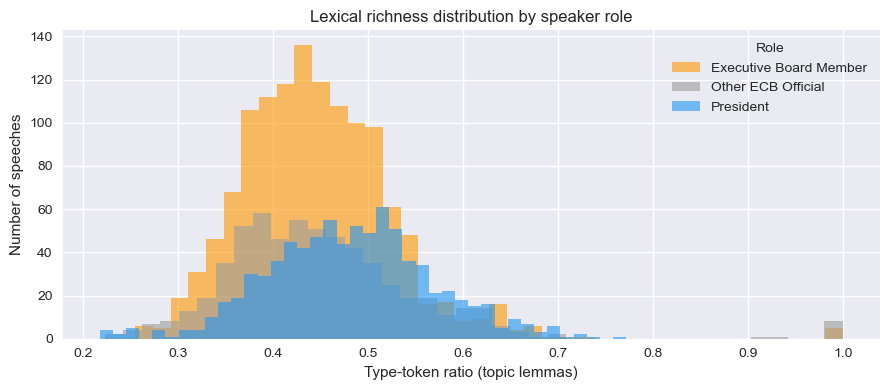

In [9]:
from IPython.display import display
from collections import Counter

# ── 7.1  Corpus summary ──────────────────────────────────────────────────────
words = df_exp["num_tok_topic"]
date_range = f"{df_exp['date'].min().date()}  →  {df_exp['date'].max().date()}"
summary = pd.DataFrame({
    "Metric": [
        "Total rows (1 row = 1 speaker × 1 speech)",
        "Unique speakers",
        "Unique roles",
        "Date range",
        "Min words / speech (topic tokens)",
        "Median words / speech (topic tokens)",
        "Max words / speech (topic tokens)",
        "Mean words / speech (topic tokens)",
    ],
    "Value": [
        len(df_exp),
        df_exp["speaker"].nunique(),
        df_exp["speaker_role"].nunique(),
        date_range,
        int(words.min()),
        int(words.median()),
        int(words.max()),
        round(words.mean(), 1),
    ]
})
print("=== 7.1  Corpus summary ===")
display(summary.set_index("Metric"))


# ── 7.2  Top-30 speakers by speech count ────────────────────────────────────
top30 = (
    df_exp.groupby(["speaker", "speaker_role"])
    .size().reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(30)
)
palette = {
    "President":              "#2196F3",
    "Executive Board Member": "#FF9800",
    "Other ECB Official":     "#9E9E9E",
}
colors = [palette.get(r, "#9E9E9E") for r in top30["speaker_role"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top30["speaker"][::-1], top30["n"][::-1], color=colors[::-1])
ax.set_xlabel("Number of speeches")
ax.set_title("Top 30 speakers by number of speeches")
handles = [plt.Rectangle((0,0),1,1, color=v) for v in palette.values()]
ax.legend(handles, palette.keys(), title="Role", loc="lower right")
plt.tight_layout()
plt.show()


# ── 7.3  Annual speech volume by role ────────────────────────────────────────
df_exp["year"] = df_exp["date"].dt.year
yr = df_exp.groupby(["year", "speaker_role"]).size().reset_index(name="n")

fig, ax = plt.subplots(figsize=(11, 5))
for role, grp in yr.groupby("speaker_role"):
    ax.plot(grp["year"], grp["n"], marker="o", label=role, linewidth=2)
ax.set_xlabel("Year")
ax.set_ylabel("Number of speeches")
ax.set_title("Annual speech count by speaker role")
ax.legend(title="Role", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# ── 7.4  Speech-length distribution by role (box plot) ───────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
roles_ordered = df_exp["speaker_role"].value_counts().index.tolist()
data_by_role = [df_exp.loc[df_exp["speaker_role"] == r, "num_tok_topic"].values
                for r in roles_ordered]
bp = ax.boxplot(data_by_role, vert=True, patch_artist=True, showfliers=False)
role_colors = [palette.get(r, "#9E9E9E") for r in roles_ordered]
for patch, col in zip(bp["boxes"], role_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(roles_ordered)+1))
ax.set_xticklabels(roles_ordered, rotation=15, ha="right")
ax.set_ylabel("Topic tokens per speech")
ax.set_title("Speech-length distribution by speaker role (outliers hidden)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# ── 7.5  Median speech length per role (table) ──────────────────────────────
print("\n=== 7.5  Word-count statistics by speaker role ===")
length_stats = (
    df_exp.groupby("speaker_role")["num_tok_topic"]
    .agg(n_speeches="count", median="median", mean="mean", std="std",
         p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
    .round(1)
    .sort_values("median", ascending=False)
)
display(length_stats)


# ── 7.6  Top-20 content words per role ───────────────────────────────────────
print("\n=== 7.6  Top 20 content words per speaker role ===")
for role in df_exp["speaker_role"].unique():
    subset = df_exp.loc[df_exp["speaker_role"] == role, "tokens_topic"]
    all_toks = [tok for toks in subset for tok in toks]
    top20 = Counter(all_toks).most_common(20)
    words_str = ", ".join(f"{w} ({c})" for w, c in top20)
    print(f"\n[{role}]\n  {words_str}")


# ── 7.7  Lexical richness (type–token ratio) by role ─────────────────────────
df_exp["ttr_topic"] = df_exp.apply(
    lambda row: (len(set(row["lemmas_topic"])) / len(row["lemmas_topic"])
                 if len(row["lemmas_topic"]) > 0 else np.nan),
    axis=1
)

print("\n=== 7.7  Lexical richness (unique lemmas / total lemmas) by role ===")
ttr_stats = (
    df_exp.groupby("speaker_role")["ttr_topic"]
    .agg(median="median", mean="mean", std="std")
    .round(3)
    .sort_values("median", ascending=False)
)
display(ttr_stats)

fig, ax = plt.subplots(figsize=(9, 4))
for role, grp in df_exp.groupby("speaker_role"):
    vals = grp["ttr_topic"].dropna()
    ax.hist(vals, bins=40, alpha=0.6, label=role,
            color=palette.get(role, "#9E9E9E"))
ax.set_xlabel("Type-token ratio (topic lemmas)")
ax.set_ylabel("Number of speeches")
ax.set_title("Lexical richness distribution by speaker role")
ax.legend(title="Role")
plt.tight_layout()
plt.show()


### 7.8  TF-IDF: distinctive words per speaker role

Instead of raw frequency counts (which surface generic ECB boilerplate for every role), TF-IDF
identifies words that are **relatively distinctive** for each role compared to the others.

**How it works here:**
- Each role's corpus is treated as a single "document" (all speeches concatenated).
- `TfidfVectorizer` computes TF-IDF scores across the three role-documents.
- Words with the highest score for a given role are the ones that appear frequently *within*
  that role but are relatively rare across the other roles.

This is entirely data-driven — no manual word removal required.

=== 7.8  Top 20 TF-IDF distinctive words per speaker role ===

[Executive Board Member]
  financial (0.0192), policy (0.0191), monetary (0.0189), banks (0.0184), market (0.0181), inflation (0.018), economic (0.018), stability (0.0177), risk (0.0173), markets (0.0173), growth (0.0173), price (0.0173), countries (0.0172), crisis (0.0172), banking (0.0171), term (0.0171), rates (0.017), economy (0.017), rate (0.0169), interest (0.0168)

[Other ECB Official]
  policy (0.0223), monetary (0.022), financial (0.0219), banks (0.0212), market (0.0211), economic (0.0208), inflation (0.0207), stability (0.0203), growth (0.0202), rate (0.0201), countries (0.02), markets (0.0199), term (0.0199), price (0.0199), risk (0.0199), rates (0.0199), banking (0.0197), inen (0.0196), sirkka (0.0195), interest (0.0195)

[President]
  policy (0.0213), monetary (0.0212), financial (0.0212), pes (0.0207), economic (0.0206), inflation (0.0203), growth (0.0202), stability (0.0201), market (0.02), price (0.0199), co

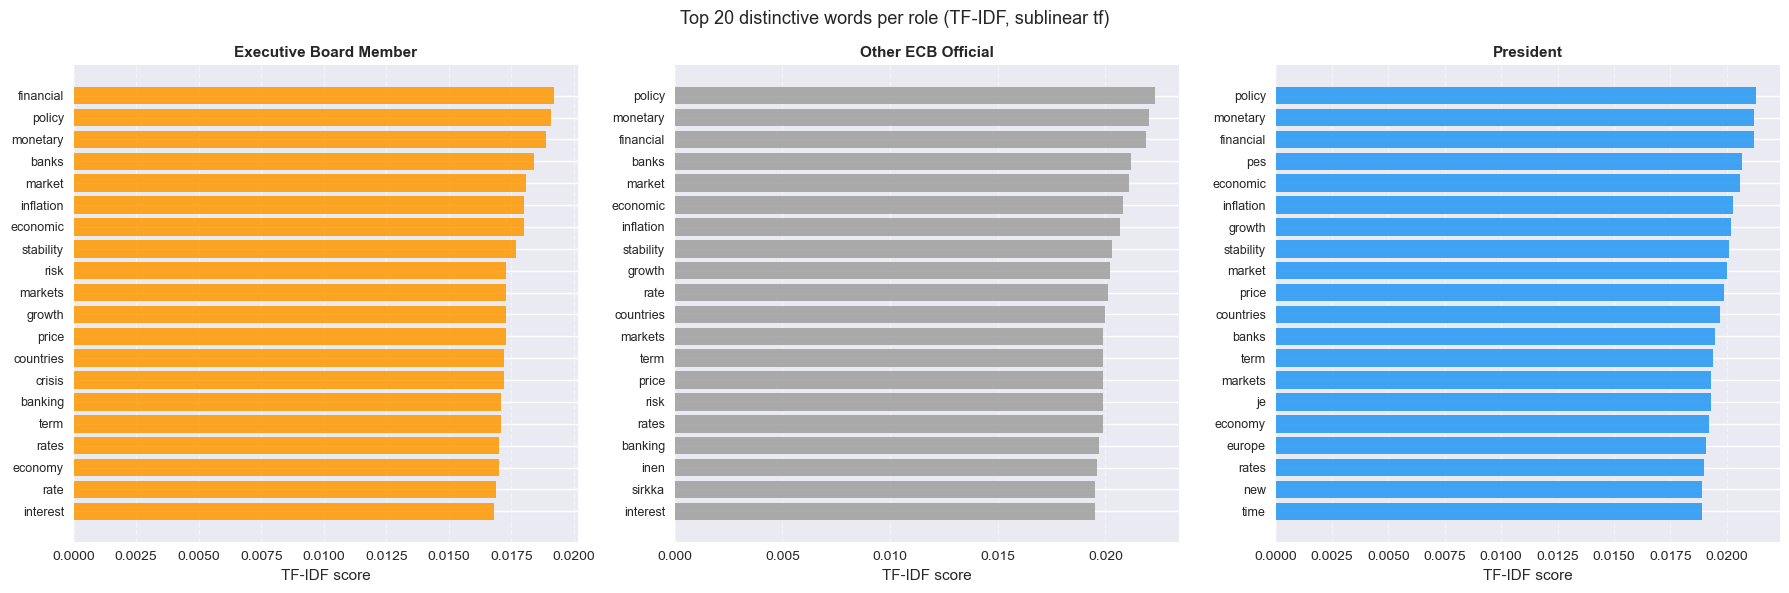

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Build one document per role (join all topic tokens) ──────────────────────
role_docs = (
    df_exp.groupby("speaker_role")["tokens_topic"]
    .apply(lambda col: " ".join(" ".join(toks) for toks in col))
    .reset_index()
    .rename(columns={"tokens_topic": "role_text"})
)

roles   = role_docs["speaker_role"].tolist()
corpora = role_docs["role_text"].tolist()

# ── Fit TF-IDF (already tokenised, so no further tokenisation needed) ─────────
vec = TfidfVectorizer(
    analyzer="word",
    token_pattern=r"[a-zA-Z'\-]{2,}",   # words of at least 2 chars
    max_features=20_000,
    sublinear_tf=True,                    # log(1+tf) dampens very common words
)
tfidf_matrix = vec.fit_transform(corpora)   # shape: (n_roles, n_vocab)
vocab = vec.get_feature_names_out()

# ── Extract top-N distinctive words per role ─────────────────────────────────
TOP_N = 20
print(f"=== 7.8  Top {TOP_N} TF-IDF distinctive words per speaker role ===\n")

role_top_words = {}
for i, role in enumerate(roles):
    scores   = tfidf_matrix[i].toarray().flatten()
    top_idx  = scores.argsort()[::-1][:TOP_N]
    top_words = [(vocab[j], round(scores[j], 4)) for j in top_idx]
    role_top_words[role] = top_words
    words_str = ", ".join(f"{w} ({s})" for w, s in top_words)
    print(f"[{role}]\n  {words_str}\n")

# ── Visualise as a grouped bar chart ─────────────────────────────────────────
palette = {
    "President":              "#2196F3",
    "Executive Board Member": "#FF9800",
    "Other ECB Official":     "#9E9E9E",
}

fig, axes = plt.subplots(1, len(roles), figsize=(6 * len(roles), 6), sharey=False)

for ax, role in zip(axes, roles):
    words_scores = role_top_words[role]
    ws = [w for w, _ in words_scores]
    ss = [s for _, s in words_scores]
    ax.barh(ws[::-1], ss[::-1], color=palette.get(role, "#9E9E9E"), alpha=0.85)
    ax.set_title(role, fontsize=11, fontweight="bold")
    ax.set_xlabel("TF-IDF score")
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.suptitle(f"Top {TOP_N} distinctive words per role (TF-IDF, sublinear tf)", fontsize=13)
plt.tight_layout()
plt.show()

## 8. (Optional) Save enriched dataset

Saves the cleaned, English-only, exploded dataset to CSV for use in downstream modelling notebooks.

In [11]:
OUTPUT_PATH = "ecb_speeches_clean_en_exploded.csv"

cols_to_save = [
    "date", "speaker", "speaker_role", "president", "language",
    "title", "subtitle", "contents", "textraw", "text_clean",
    "num_tok_topic", "num_lem_topic", "num_tok_sent", "num_lem_sent"
]
df_exp[cols_to_save].to_csv(OUTPUT_PATH, index=False)
print(f"Saved to {OUTPUT_PATH}  ({len(df_exp)} rows)")

Saved to ecb_speeches_clean_en_exploded.csv  (2671 rows)


## 9. Frequency Distributions — Top 50 Unigrams & Bigrams

Compute the most frequent unigrams and bigrams across the full corpus using topic tokens (domain stopwords already removed). Visualise with bar charts.

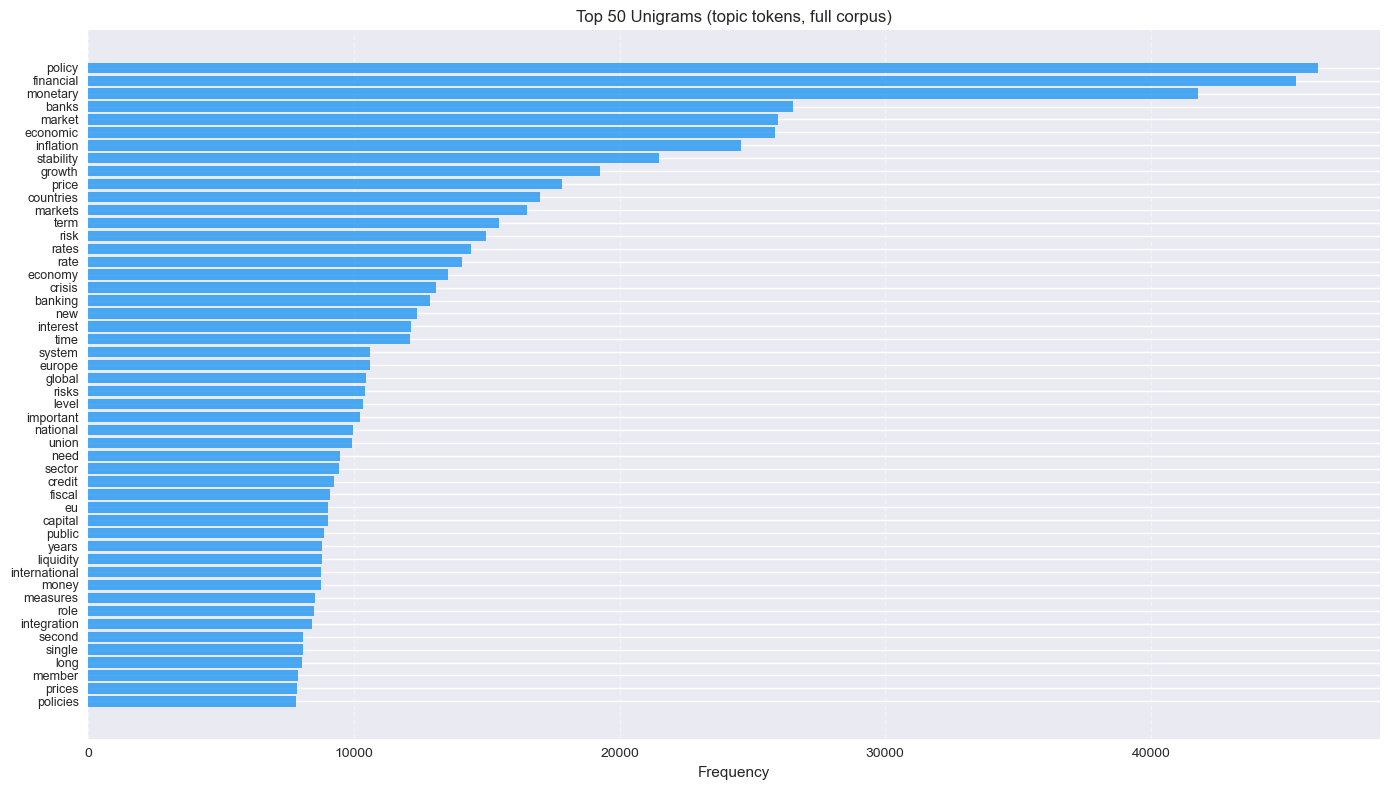

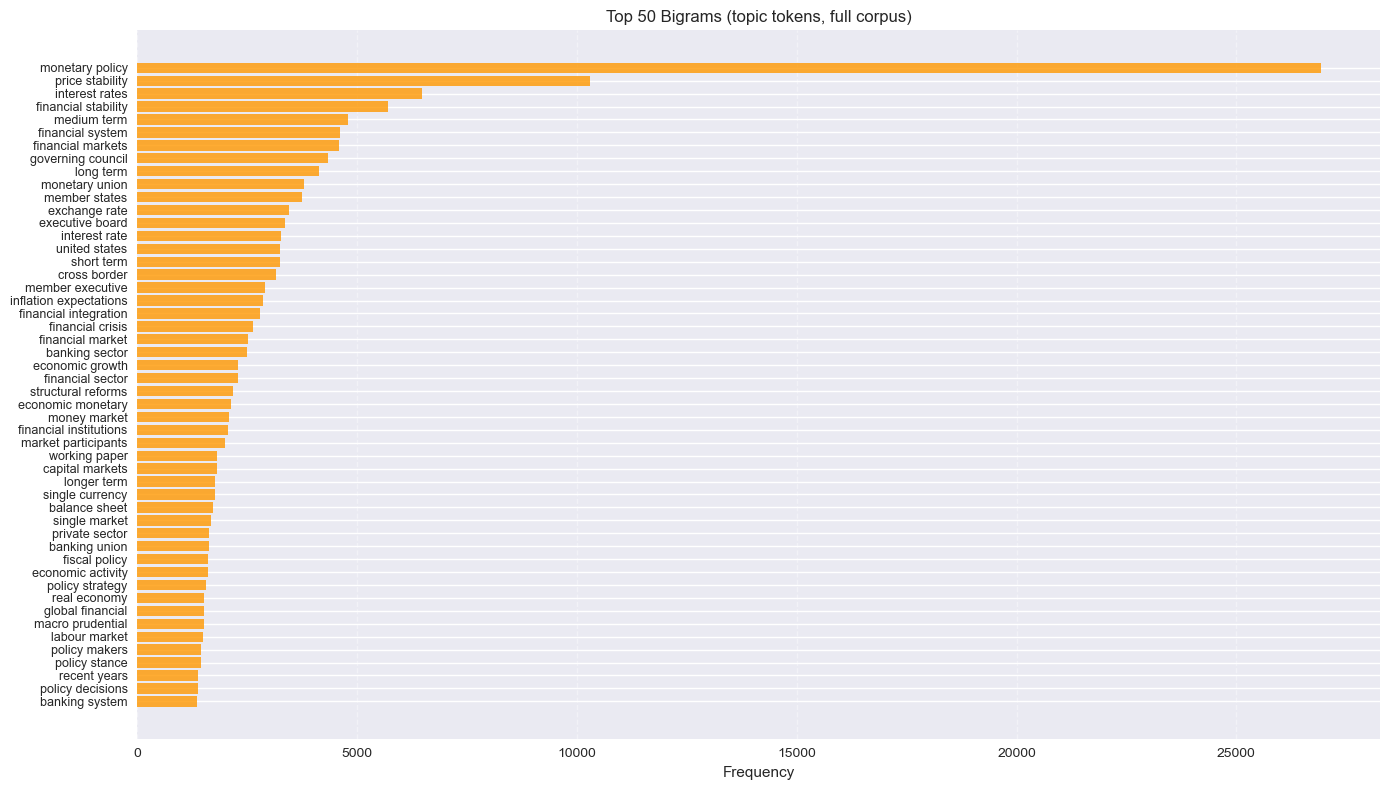

Vocabulary size: 55,099 unique tokens (digits excluded)
Total tokens: 3,996,074
Unique bigrams: 1,480,303


In [12]:
from collections import Counter
from itertools import islice

# ── 9.1 Top 50 unigrams ─────────────────────────────────────────────────────
# Filter out pure-digit tokens (year fragments, footnote numbers, etc.)
all_tokens = [tok for toks in df_exp["tokens_topic"] for tok in toks if not tok.isdigit()]
uni_counts = Counter(all_tokens)
top50_uni = uni_counts.most_common(50)

fig, ax = plt.subplots(figsize=(14, 8))
words, counts = zip(*top50_uni)
ax.barh(range(len(words)), counts[::-1], color="#2196F3", alpha=0.8)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words[::-1], fontsize=9)
ax.set_xlabel("Frequency")
ax.set_title("Top 50 Unigrams (topic tokens, full corpus)")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── 9.2 Top 50 bigrams ──────────────────────────────────────────────────────
def get_bigrams(token_list):
    # Skip bigrams containing pure digits
    return [(a, b) for a, b in zip(token_list[:-1], token_list[1:])
            if not a.isdigit() and not b.isdigit()]

all_bigrams = [bg for toks in df_exp["tokens_topic"] for bg in get_bigrams(toks)]
bi_counts = Counter(all_bigrams)
top50_bi = bi_counts.most_common(50)

fig, ax = plt.subplots(figsize=(14, 8))
labels = [f"{w1} {w2}" for (w1, w2), _ in top50_bi]
counts_bi = [c for _, c in top50_bi]
ax.barh(range(len(labels)), counts_bi[::-1], color="#FF9800", alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels[::-1], fontsize=9)
ax.set_xlabel("Frequency")
ax.set_title("Top 50 Bigrams (topic tokens, full corpus)")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Vocabulary size: {len(uni_counts):,} unique tokens (digits excluded)")
print(f"Total tokens: {len(all_tokens):,}")
print(f"Unique bigrams: {len(bi_counts):,}")

## 10. Word Clouds

- Full corpus word cloud
- Word clouds split by speaker role (President, Executive Board Member, Other ECB Official)

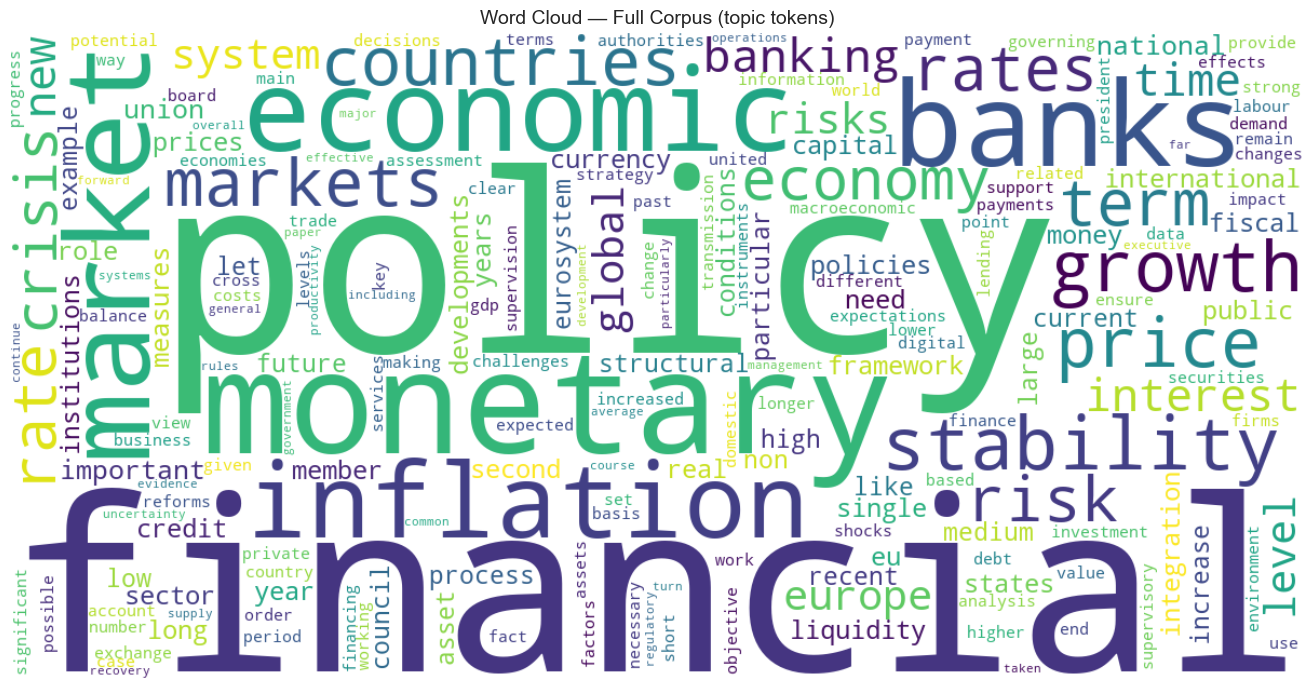

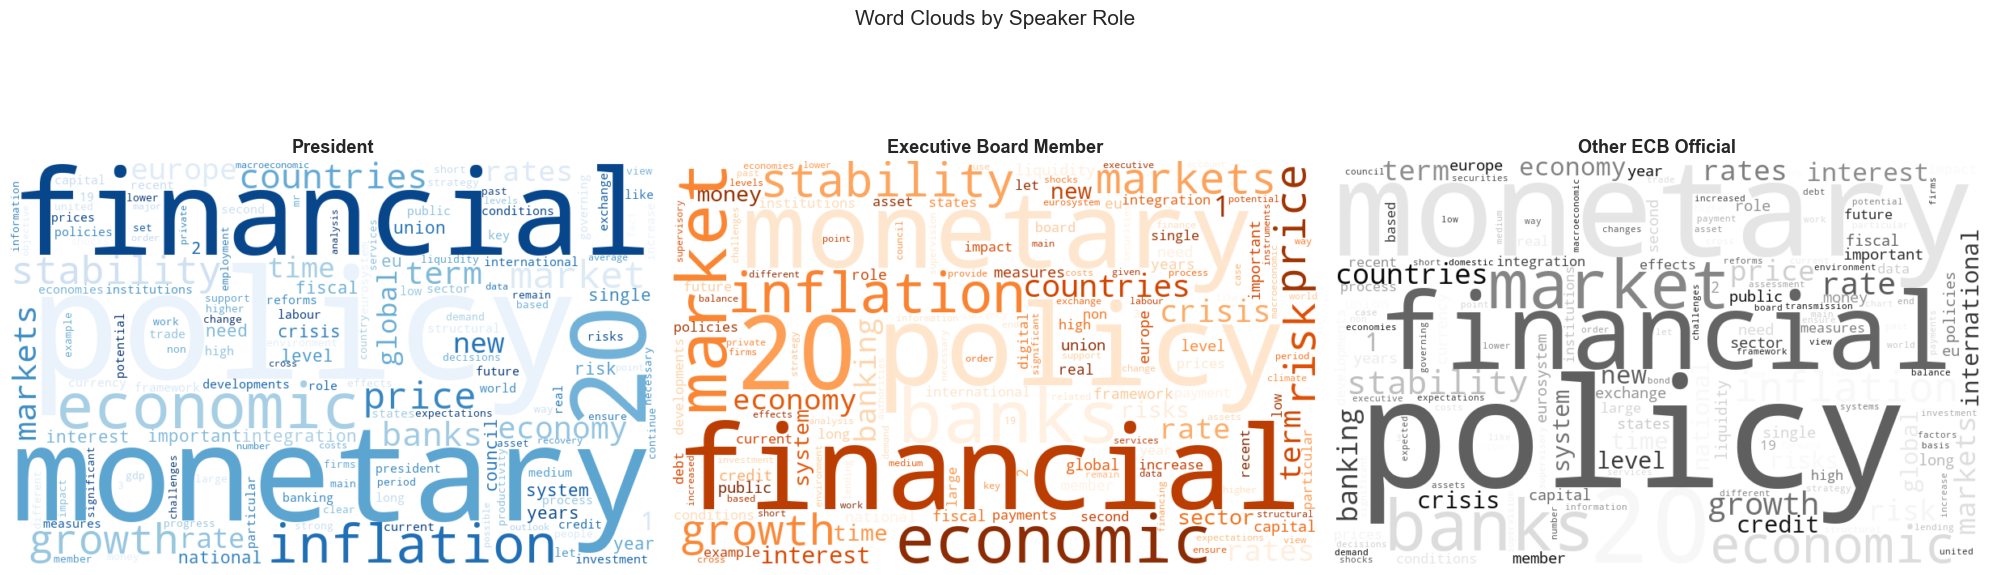

In [13]:
from wordcloud import WordCloud

# ── 10.1 Full corpus word cloud ─────────────────────────────────────────────
wc_full = WordCloud(width=1200, height=600, max_words=200,
                    background_color="white", colormap="viridis",
                    collocations=False)
wc_full.generate_from_frequencies(uni_counts)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc_full, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word Cloud — Full Corpus (topic tokens)", fontsize=14)
plt.tight_layout()
plt.show()

# ── 10.2 Word clouds by speaker role ────────────────────────────────────────
roles = ["President", "Executive Board Member", "Other ECB Official"]
role_colors = {"President": "Blues", "Executive Board Member": "Oranges",
               "Other ECB Official": "Greys"}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, role in zip(axes, roles):
    subset = df_exp[df_exp["speaker_role"] == role]
    role_tokens = [tok for toks in subset["tokens_topic"] for tok in toks]
    role_freq = Counter(role_tokens)
    wc = WordCloud(width=800, height=500, max_words=150,
                   background_color="white", colormap=role_colors[role],
                   collocations=False)
    wc.generate_from_frequencies(role_freq)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(role, fontsize=13, fontweight="bold")

fig.suptitle("Word Clouds by Speaker Role", fontsize=15)
plt.tight_layout()
plt.show()

## 11. Corpus Statistics Summary

Overview of the corpus: speech counts, token distributions, temporal coverage.

,Value
Total speeches (rows),2671
Unique speakers,28
Unique speech dates,2095
Date range,1997-02-07 to 2026-03-26
Years covered,30
Avg tokens/speech (topic),1535
Median tokens/speech (topic),1366
Total tokens (topic),"4,098,720"
Vocabulary size (unique),"55,099"


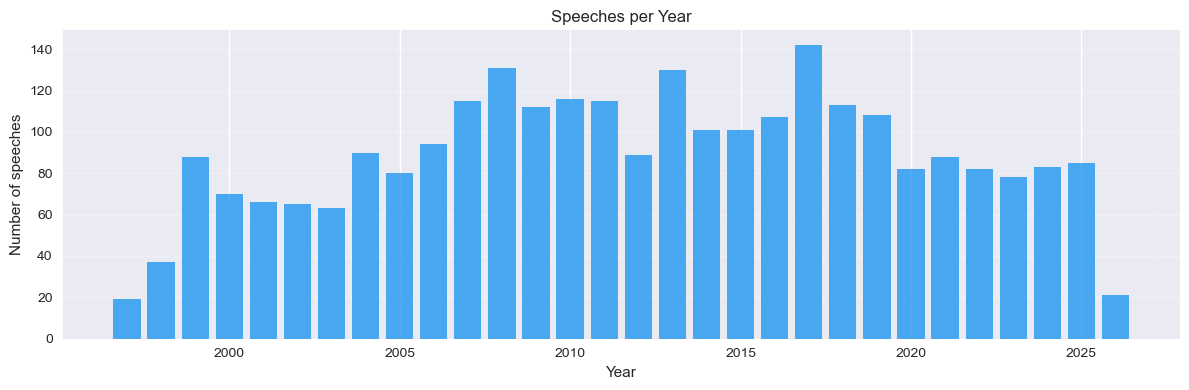

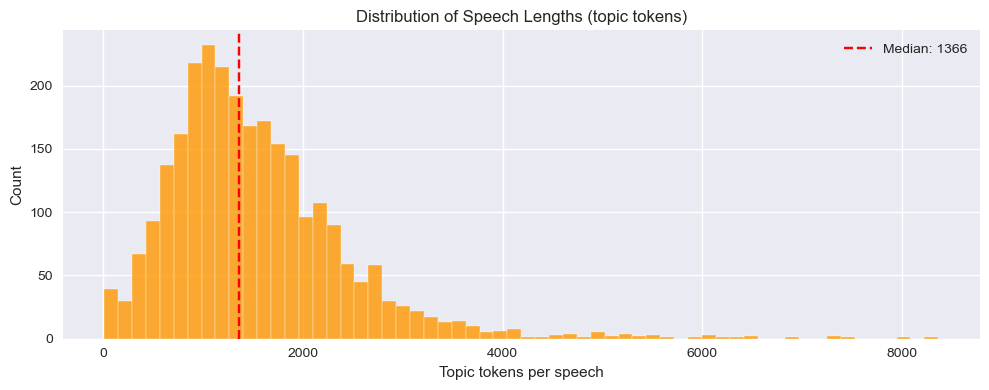

=== Step 2 (Descriptive Analysis) complete ===


In [14]:
from IPython.display import display

# ── 11.1 Basic statistics ────────────────────────────────────────────────────
df_exp["year"] = df_exp["date"].dt.year

stats = {
    "Total speeches (rows)": len(df_exp),
    "Unique speakers": df_exp["speaker"].nunique(),
    "Unique speech dates": df_exp["date"].nunique(),
    "Date range": f"{df_exp['date'].min().date()} to {df_exp['date'].max().date()}",
    "Years covered": int(df_exp["year"].max() - df_exp["year"].min() + 1),
    "Avg tokens/speech (topic)": f"{df_exp['num_tok_topic'].mean():.0f}",
    "Median tokens/speech (topic)": f"{df_exp['num_tok_topic'].median():.0f}",
    "Total tokens (topic)": f"{df_exp['num_tok_topic'].sum():,}",
    "Vocabulary size (unique)": f"{len(uni_counts):,}",
}
display(pd.DataFrame.from_dict(stats, orient="index", columns=["Value"]))

# ── 11.2 Speeches over time ─────────────────────────────────────────────────
yearly = df_exp.groupby("year").size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(yearly.index, yearly.values, color="#2196F3", alpha=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Number of speeches")
ax.set_title("Speeches per Year")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── 11.3 Token length distribution ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_exp["num_tok_topic"], bins=60, color="#FF9800", alpha=0.8, edgecolor="white")
ax.axvline(df_exp["num_tok_topic"].median(), color="red", linestyle="--", label=f"Median: {df_exp['num_tok_topic'].median():.0f}")
ax.set_xlabel("Topic tokens per speech")
ax.set_ylabel("Count")
ax.set_title("Distribution of Speech Lengths (topic tokens)")
ax.legend()
plt.tight_layout()
plt.show()

print("=== Step 2 (Descriptive Analysis) complete ===")

## 12. Topic Modelling — LDA with Coherence Search

- Build a gensim dictionary and bag-of-words corpus from topic lemmas
- Search over k = 5..20 topics using c_v coherence
- Plot the coherence curve and select the optimal k
- Display top 10 words per topic with human-readable labels

In [15]:
from gensim import corpora, models
from gensim.models import CoherenceModel

# ── 12.1 Build dictionary and corpus ────────────────────────────────────────
texts_for_lda = df_exp["lemmas_topic"].tolist()

dictionary = corpora.Dictionary(texts_for_lda)
# Filter extremes: remove tokens in <5 docs or >60% of docs
dictionary.filter_extremes(no_below=5, no_above=0.6)
corpus_bow = [dictionary.doc2bow(doc) for doc in texts_for_lda]

print(f"Dictionary size: {len(dictionary)} terms")
print(f"Corpus size: {len(corpus_bow)} documents")

# ── 12.2 Coherence search over k = 5..20 ────────────────────────────────────
K_RANGE = range(5, 21)
coherence_scores = []

print("Running LDA coherence search (this may take several minutes)...")
for k in K_RANGE:
    lda = models.LdaModel(
        corpus_bow, num_topics=k, id2word=dictionary,
        passes=10, iterations=100, random_state=42
    )
    cm = CoherenceModel(model=lda, texts=texts_for_lda, dictionary=dictionary, coherence="c_v")
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"  k={k:2d}  coherence={score:.4f}")

print("\nCoherence search complete.")

Dictionary size: 12445 terms
Corpus size: 2671 documents
Running LDA coherence search (this may take several minutes)...
  k= 5  coherence=0.4482
  k= 6  coherence=0.4973
  k= 7  coherence=0.4859
  k= 8  coherence=0.4931
  k= 9  coherence=0.5309
  k=10  coherence=0.5571
  k=11  coherence=0.5266
  k=12  coherence=0.5498
  k=13  coherence=0.5109
  k=14  coherence=0.5458
  k=15  coherence=0.5334
  k=16  coherence=0.5599
  k=17  coherence=0.5467
  k=18  coherence=0.5226
  k=19  coherence=0.5278
  k=20  coherence=0.5324

Coherence search complete.


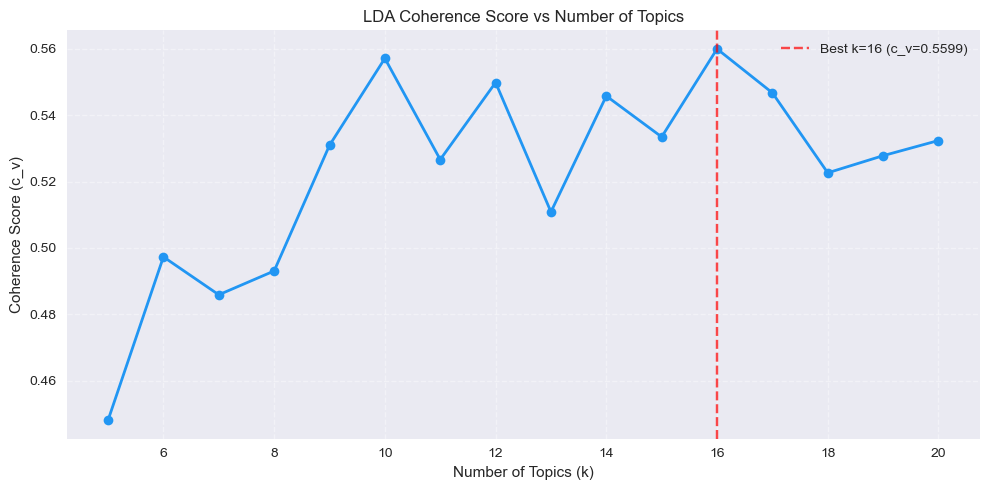


Optimal k = 16 with coherence = 0.5599


In [16]:
# ── 12.3 Coherence curve ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(K_RANGE), coherence_scores, marker="o", linewidth=2, color="#2196F3")
best_idx = coherence_scores.index(max(coherence_scores))
best_k = list(K_RANGE)[best_idx]
ax.axvline(best_k, color="red", linestyle="--", alpha=0.7, label=f"Best k={best_k} (c_v={max(coherence_scores):.4f})")
ax.set_xlabel("Number of Topics (k)")
ax.set_ylabel("Coherence Score (c_v)")
ax.set_title("LDA Coherence Score vs Number of Topics")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nOptimal k = {best_k} with coherence = {max(coherence_scores):.4f}")

In [17]:
# ── 12.4 Train final LDA model with optimal k ──────────────────────────────
lda_best = models.LdaModel(
    corpus_bow, num_topics=best_k, id2word=dictionary,
    passes=20, iterations=200, random_state=42
)

# Display top 10 words per topic
print(f"=== LDA Model: {best_k} topics ===\n")
for topic_id in range(best_k):
    top_words = lda_best.show_topic(topic_id, topn=10)
    words_str = ", ".join(f"{w} ({p:.3f})" for w, p in top_words)
    print(f"Topic {topic_id:2d}: {words_str}")

=== LDA Model: 16 topics ===

Topic  0: purchase (0.011), liquidity (0.011), expectation (0.007), outlook (0.006), operation (0.006), month (0.006), lending (0.006), balance (0.005), loan (0.005), transmission (0.005)
Topic  1: supervisory (0.018), supervision (0.017), authority (0.010), prudential (0.010), supervisor (0.009), regulation (0.009), climate (0.008), regulatory (0.007), macro (0.006), systemic (0.006)
Topic  2: parliament (0.014), de (0.013), annual (0.012), oil (0.011), committee (0.011), council (0.010), la (0.010), govern (0.008), report (0.008), outlook (0.007)
Topic  3: fiscal (0.034), government (0.018), debt (0.014), rule (0.011), deficit (0.008), sovereign (0.007), reform (0.007), mechanism (0.005), finance (0.005), governance (0.005)
Topic  4: labour (0.022), reform (0.016), productivity (0.013), structural (0.012), wage (0.008), employment (0.008), average (0.007), 19 (0.007), shock (0.007), factor (0.006)
Topic  5: ccp (0.024), macroprudential (0.023), clearing 

### 12.5 Topic Labels

After inspecting the top words, assign a short human-readable label to each topic. Edit the `TOPIC_LABELS` dictionary below after reviewing the output above.

Provisional topic labels:
  Topic  0: purchase / liquidity / expectation
  Topic  1: supervisory / supervision / authority
  Topic  2: parliament / de / annual
  Topic  3: fiscal / government / debt
  Topic  4: labour / reform / productivity
  Topic  5: ccp / macroprudential / clearing
  Topic  6: reform / structural / gdp
  Topic  7: paper / shock / pandemic
  Topic  8: currency / exchange / trade
  Topic  9: liquidity / bond / fund
  Topic 10: integration / security / border
  Topic 11: strategy / money / analysis
  Topic 12: banknote / statistic / coin
  Topic 13: question / think / political
  Topic 14: payment / digital / sepa
  Topic 15: exchange / council / convergence

Topic distribution across speeches:
topic_label
purchase / liquidity / expectation       411
supervisory / supervision / authority    361
fiscal / government / debt               210
paper / shock / pandemic                 186
exchange / council / convergence         168
payment / digital / sepa                 

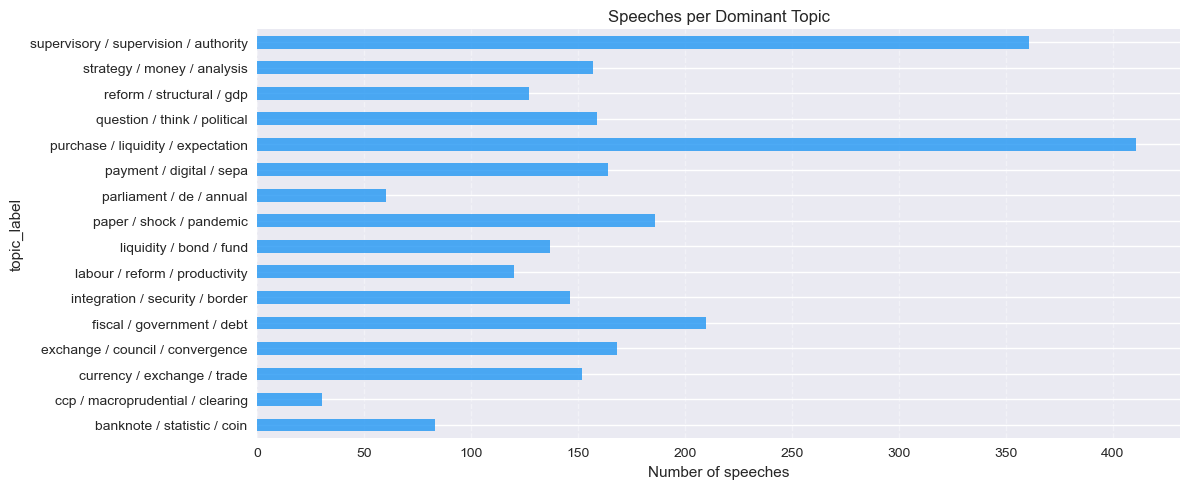

In [18]:
# ── 12.5 Auto-generate topic labels from top words ──────────────────────────
# Use the top 3 words as a provisional label; refine manually if desired.
TOPIC_LABELS = {}
for topic_id in range(best_k):
    top3 = [w for w, _ in lda_best.show_topic(topic_id, topn=3)]
    TOPIC_LABELS[topic_id] = " / ".join(top3)

print("Provisional topic labels:")
for tid, label in TOPIC_LABELS.items():
    print(f"  Topic {tid:2d}: {label}")

# ── 12.6 Assign dominant topic to each speech ───────────────────────────────
def get_dominant_topic(bow):
    topic_probs = lda_best.get_document_topics(bow, minimum_probability=0.0)
    return max(topic_probs, key=lambda x: x[1])

dominant = [get_dominant_topic(bow) for bow in corpus_bow]
df_exp["dominant_topic"] = [t for t, _ in dominant]
df_exp["topic_prob"] = [p for _, p in dominant]
df_exp["topic_label"] = df_exp["dominant_topic"].map(TOPIC_LABELS)

print(f"\nTopic distribution across speeches:")
print(df_exp["topic_label"].value_counts())

# ── 12.7 Topic distribution bar chart ───────────────────────────────────────
topic_dist = df_exp["topic_label"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 5))
topic_dist.plot(kind="barh", ax=ax, color="#2196F3", alpha=0.8)
ax.set_xlabel("Number of speeches")
ax.set_title("Speeches per Dominant Topic")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [19]:
# ── 12.8 pyLDAvis interactive visualisation ─────────────────────────────────
import pyLDAvis
import pyLDAvis.gensim_models

vis_data = pyLDAvis.gensim_models.prepare(lda_best, corpus_bow, dictionary, sort_topics=False)
pyLDAvis.display(vis_data)

## 13. Classification — SVC & XGBoost on Dominant Topic

- Target: dominant LDA topic (from Step 12)
- Features: TF-IDF on topic tokens
- Models: LinearSVC and XGBoost with GridSearchCV
- Metrics: accuracy, macro F1, confusion matrix

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import xgboost as xgb

# ── 13.1 Prepare features and target ────────────────────────────────────────
# Join topic tokens back into strings for TF-IDF
df_exp["tokens_topic_str"] = df_exp["tokens_topic"].apply(lambda toks: " ".join(toks))
X = df_exp["tokens_topic_str"]
y = df_exp["dominant_topic"]

print(f"Classes: {sorted(y.unique())}")
print(f"Class distribution:\n{y.value_counts().sort_index()}")

# Train/test split (stratified)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")

Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
Class distribution:
dominant_topic
0     411
1     361
2      60
3     210
4     120
5      30
6     127
7     186
8     152
9     137
10    146
11    157
12     83
13    159
14    164
15    168
Name: count, dtype: int64

Train: 2136, Test: 535


Fitting 5 folds for each of 6 candidates, totalling 30 fits


/opt/miniconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/miniconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/miniconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _Forkin


Best SVC params: {'svc__C': 1.0, 'tfidf__max_features': 10000}
Best CV F1 (macro): 0.8155

=== LinearSVC — Test Set ===
              precision    recall  f1-score   support

           0       0.86      0.93      0.89        82
           1       0.85      0.94      0.89        72
           2       1.00      0.75      0.86        12
           3       0.84      0.76      0.80        42
           4       0.95      0.88      0.91        24
           5       1.00      0.50      0.67         6
           6       0.74      0.56      0.64        25
           7       0.71      0.73      0.72        37
           8       0.81      0.84      0.83        31
           9       0.73      0.59      0.65        27
          10       0.96      0.79      0.87        29
          11       0.87      0.81      0.84        32
          12       0.79      0.65      0.71        17
          13       0.74      0.81      0.78        32
          14       0.86      0.97      0.91        33
          15  

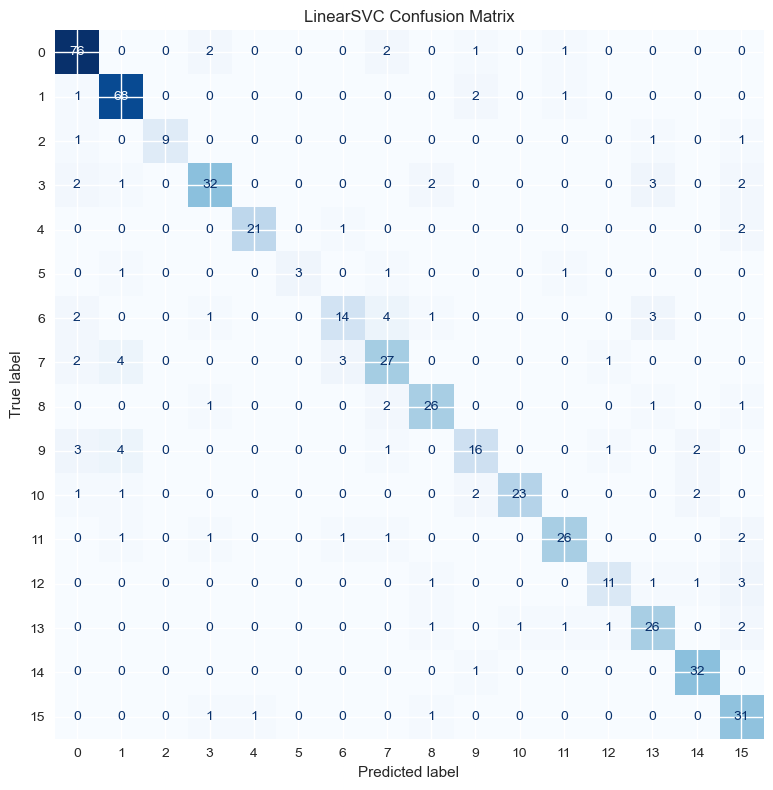

In [21]:
# ── 13.2 LinearSVC with GridSearchCV ─────────────────────────────────────────
svc_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=15000, sublinear_tf=True, ngram_range=(1, 2))),
    ("svc", LinearSVC(max_iter=5000, random_state=42))
])

svc_params = {
    "svc__C": [0.1, 1.0, 10.0],
    "tfidf__max_features": [10000, 15000],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svc_grid = GridSearchCV(svc_pipe, svc_params, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1)
svc_grid.fit(X_train, y_train)

print(f"\nBest SVC params: {svc_grid.best_params_}")
print(f"Best CV F1 (macro): {svc_grid.best_score_:.4f}")

y_pred_svc = svc_grid.predict(X_test)
print("\n=== LinearSVC — Test Set ===")
print(classification_report(y_test, y_pred_svc, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc, ax=ax, cmap="Blues", colorbar=False)
ax.set_title("LinearSVC Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
# ── 13.3 XGBoost with GridSearchCV ───────────────────────────────────────────
xgb_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=15000, sublinear_tf=True, ngram_range=(1, 2))),
    ("xgb", xgb.XGBClassifier(
        objective="multi:softmax",
        eval_metric="mlogloss",
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_params = {
    "xgb__n_estimators": [100, 200],
    "xgb__max_depth": [4, 6],
    "xgb__learning_rate": [0.1, 0.3],
}

xgb_grid = GridSearchCV(xgb_pipe, xgb_params, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

print(f"\nBest XGBoost params: {xgb_grid.best_params_}")
print(f"Best CV F1 (macro): {xgb_grid.best_score_:.4f}")

y_pred_xgb = xgb_grid.predict(X_test)
print("\n=== XGBoost — Test Set ===")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=ax, cmap="Oranges", colorbar=False)
ax.set_title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

# ── 13.4 Model comparison ───────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score
comparison = pd.DataFrame({
    "Model": ["LinearSVC", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred_svc), accuracy_score(y_test, y_pred_xgb)],
    "F1 (macro)": [f1_score(y_test, y_pred_svc, average="macro", zero_division=0),
                   f1_score(y_test, y_pred_xgb, average="macro", zero_division=0)],
    "Best CV F1": [svc_grid.best_score_, xgb_grid.best_score_],
})
display(comparison.set_index("Model"))
print("\n=== Step 4a (Classical Classification) complete ===")

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [00:37:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [00:37:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [00:37:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [00:37:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iterati

KeyboardInterrupt: 

## 14. LLM-Based Sentiment Analysis (Anthropic API)

- Draw a stratified sample of 150 speeches (stratified by dominant topic)
- Send each to Claude Sonnet with a zero-shot prompt asking for hawkish/dovish/neutral classification + justification
- Parse results and compare against classical model predictions

In [ ]:
import anthropic
import json
import time

client = anthropic.Anthropic()  # uses ANTHROPIC_API_KEY env var

# ── 14.1 Stratified sample ──────────────────────────────────────────────────
SAMPLE_SIZE = 150
sample = (
    df_exp.groupby("dominant_topic", group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), max(1, int(SAMPLE_SIZE * len(g) / len(df_exp)))),
                               random_state=42))
    .reset_index(drop=True)
)
# Top up or trim to exactly SAMPLE_SIZE
if len(sample) < SAMPLE_SIZE:
    remaining = df_exp[~df_exp.index.isin(sample.index)].sample(
        n=SAMPLE_SIZE - len(sample), random_state=42)
    sample = pd.concat([sample, remaining]).reset_index(drop=True)
elif len(sample) > SAMPLE_SIZE:
    sample = sample.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print(f"Sample size: {len(sample)}")
print(f"Topic distribution in sample:\n{sample['dominant_topic'].value_counts().sort_index()}")

# ── 14.2 LLM classification ─────────────────────────────────────────────────
SYSTEM_PROMPT = """You are an expert in monetary policy analysis. You will be given an excerpt from an ECB speech. Classify the monetary policy stance as exactly one of: hawkish, dovish, or neutral.

Respond ONLY with valid JSON in this exact format:
{"sentiment": "hawkish|dovish|neutral", "justification": "one sentence explanation"}"""

def classify_speech(text, max_chars=3000):
    """Send a truncated speech to Claude for sentiment classification."""
    truncated = text[:max_chars]
    try:
        response = client.messages.create(
            model="claude-sonnet-4-20250514",
            max_tokens=150,
            system=SYSTEM_PROMPT,
            messages=[{"role": "user", "content": truncated}]
        )
        raw = response.content[0].text.strip()
        return json.loads(raw)
    except (json.JSONDecodeError, Exception) as e:
        return {"sentiment": "error", "justification": str(e)}

results = []
print("Classifying speeches with Claude Sonnet...")
for i, row in sample.iterrows():
    result = classify_speech(row["text_clean"])
    result["idx"] = i
    results.append(result)
    if (len(results)) % 25 == 0:
        print(f"  {len(results)}/{len(sample)} done...")
    time.sleep(0.3)  # rate limiting

print(f"\nClassification complete. {len(results)} speeches processed.")

# Parse results
sample["llm_sentiment"] = [r["sentiment"] for r in results]
sample["llm_justification"] = [r["justification"] for r in results]

errors = sample[sample["llm_sentiment"] == "error"]
print(f"Errors: {len(errors)}")
print(f"\nLLM sentiment distribution:")
print(sample["llm_sentiment"].value_counts())

In [ ]:
# ── 14.3 Compare LLM sentiment with dominant topic ──────────────────────────
# Cross-tabulation: LLM sentiment vs dominant topic
valid_sample = sample[sample["llm_sentiment"].isin(["hawkish", "dovish", "neutral"])].copy()

ct = pd.crosstab(valid_sample["topic_label"], valid_sample["llm_sentiment"],
                 margins=True, margins_name="Total")
print("=== Cross-tabulation: LDA Topic vs LLM Sentiment ===")
display(ct)

# ── 14.4 Sentiment distribution by topic (stacked bar) ──────────────────────
ct_norm = pd.crosstab(valid_sample["topic_label"], valid_sample["llm_sentiment"], normalize="index")
sentiment_colors = {"hawkish": "#E53935", "dovish": "#43A047", "neutral": "#9E9E9E"}

fig, ax = plt.subplots(figsize=(12, 6))
ct_norm.plot(kind="barh", stacked=True, ax=ax,
             color=[sentiment_colors.get(c, "#666") for c in ct_norm.columns])
ax.set_xlabel("Proportion")
ax.set_title("LLM Monetary Policy Sentiment by LDA Topic")
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── 14.5 Sentiment over time ────────────────────────────────────────────────
valid_sample["year"] = valid_sample["date"].dt.year
sent_by_year = pd.crosstab(valid_sample["year"], valid_sample["llm_sentiment"], normalize="index")

fig, ax = plt.subplots(figsize=(12, 5))
for sent, color in sentiment_colors.items():
    if sent in sent_by_year.columns:
        ax.plot(sent_by_year.index, sent_by_year[sent], marker="o", label=sent, color=color, linewidth=2)
ax.set_xlabel("Year")
ax.set_ylabel("Proportion of speeches")
ax.set_title("LLM Sentiment Trend Over Time (sample)")
ax.legend(title="Sentiment")
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── 14.6 Sample justifications ──────────────────────────────────────────────
print("\n=== Sample LLM Justifications ===")
for sent in ["hawkish", "dovish", "neutral"]:
    subset = valid_sample[valid_sample["llm_sentiment"] == sent].head(3)
    print(f"\n[{sent.upper()}]")
    for _, row in subset.iterrows():
        print(f"  {row['date'].date()} | {row['speaker']}: {row['llm_justification']}")

# ── 14.7 Save LLM results ───────────────────────────────────────────────────
valid_sample[["date", "speaker", "topic_label", "llm_sentiment", "llm_justification"]].to_csv(
    "llm_sentiment_results.csv", index=False
)
print(f"\nSaved LLM sentiment results to llm_sentiment_results.csv ({len(valid_sample)} rows)")
print("\n=== Pipeline complete ===")